# Библиотеки

In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from pathlib import Path
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import CountVectorizer
from stop_words import get_stop_words
import matplotlib.pyplot as plt
from scipy.stats import entropy
import re
from nltk.corpus import stopwords
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

# Загрузка датасета

Из из наального датасета нам нужны поля subject, body, queue, priority, type

In [4]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

df = dataset["train"].to_pandas()

print("Shape:", df.shape)
df.head()

Shape: (61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [5]:
print(df.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')


In [6]:
def load_idx(path):
    with open(path) as f:
        return [int(x.strip()) for x in f.readlines()]

train_idx = load_idx("data/train_idx.txt")
val_idx   = load_idx("data/val_idx.txt")
test_idx  = load_idx("data/test_idx.txt")

print(len(train_idx), len(val_idx), len(test_idx))

49412 6176 6177


In [7]:
train_df = df.iloc[train_idx].copy()
val_df   = df.iloc[val_idx].copy()
test_df  = df.iloc[test_idx].copy()

In [8]:
def make_text(data):
    return (data["subject"].fillna("") + " " + data["body"].fillna("")).str.strip()

train_df["text"] = make_text(train_df)
val_df["text"]   = make_text(val_df)
test_df["text"]  = make_text(test_df)

# EDA

**Распределение по депаратментам**

In [11]:
train_df["queue"].value_counts().head(10)

queue
Technical Support                  11354
Product Support                     7139
Customer Service                    5905
IT Support                          4673
Billing and Payments                3853
Returns and Exchanges               1956
Service Outages and Maintenance     1534
Sales and Pre-Sales                 1228
Human Resources                      730
General Inquiry                      532
Name: count, dtype: int64

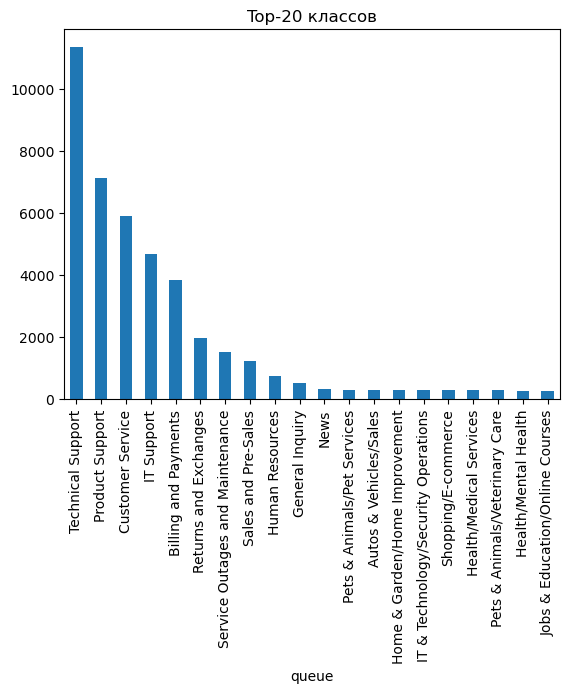

In [12]:
train_df["queue"].value_counts().head(20).plot(kind="bar")
plt.title("Top-20 классов")
plt.show()

По данным виден явный дисбаланс классов по департаментам. поэтому использование макро метрики оправдано.

**Распределение по прироритету и типу обращения**

In [14]:
print(train_df["priority"].value_counts())
print(train_df["type"].value_counts())

priority
medium      18629
high        17546
low         10280
critical     1516
very_low     1441
Name: count, dtype: int64
type
Incident    15632
Request     11165
Problem      8103
Change       4004
Name: count, dtype: int64


По этим категориям дисбаланс не такой выраженный, но тоже есть. Большинтство категорий имеют средний и сильный приорит.

По типу большинство инциденты или запросы.

**Характеристики текста по числу слов**

In [16]:
train_df["len"] = train_df["text"].str.len()
train_df["len"].describe()


count    49412.000000
mean       463.666579
std        226.852141
min          4.000000
25%        278.000000
50%        459.000000
75%        633.000000
max       2284.000000
Name: len, dtype: float64

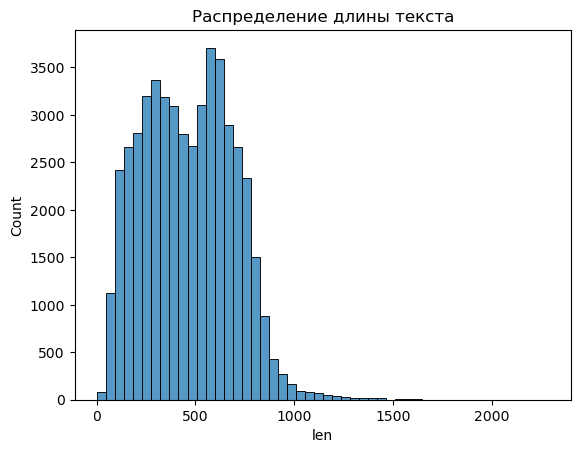

In [17]:
sns.histplot(train_df["len"], bins=50)
plt.title("Распределение длины текста")
plt.show()

Тексты имеют среднюю длину 464 символа с двумя выраженными пиками (около 300 и 600 знаков), что указывает на наличие двух разных типов контента в данных.
Для обучения стоит отсеять слишком короткие записи (минимум 4 символа) и увеличить max_features, так как 30 слов физически не смогут описать тексты такого объема.

**Распределение по группам**

In [19]:
train_df.groupby("queue")["len"].mean().sort_values().tail(20)

queue
Travel & Transportation/Land Travel     584.296296
Autos & Vehicles/Maintenance            586.755274
Real Estate                             589.898396
Finance/Investments                     590.796154
Business & Industrial/Manufacturing     592.962963
Hobbies & Leisure/Collectibles          596.634981
Jobs & Education/Recruitment            596.902128
Pets & Animals/Pet Services             597.006494
Food & Drink/Restaurants                600.357759
Finance/Personal Finance                602.098425
IT & Technology/Software Development    602.160194
Travel & Transportation/Air Travel      603.133603
Law & Government/Government Services    603.340000
Online Communities/Forums               604.200743
Science/Research                        606.827004
Pets & Animals/Veterinary Care          609.435252
Online Communities/Social Networks      613.348485
Home & Garden/Landscaping               613.552995
Arts & Entertainment/Movies             627.251208
Home & Garden/Home Improv

In [20]:
train_df.groupby("type")["len"].mean()

type
Change      476.444555
Incident    418.846277
Problem     415.356041
Request     443.835826
Name: len, dtype: float64

In [21]:
train_df.groupby("priority")["len"].mean()

priority
critical    590.849604
high        449.111478
low         466.483463
medium      457.359493
very_low    568.532269
Name: len, dtype: float64

Самые длинные и подробные тексты (560–590 симв.) характерны для  критических заявок, где важна каждая деталь, и очень низких по приоритету, которые часто содержат развернутый фидбек или идеи.
Техническая рутина (IT, HR, инциденты) описывается кратко и по делу, в то время как специфические темы вроде медицины или шопинга требуют от пользователей большего количества пояснений.

**Распределение по train/test/val**

Итого у нас достаточно много категорий исключительно с немецким языком, при этом групп эксклюзивно с английским языком нет. 

# Бейслайн (TF-IDF + Logreg) без пердобработки

In [38]:
y_pred = clf.predict(X_test)

macro_f1 = f1_score(test_df["queue"], y_pred, average="macro")
acc = accuracy_score(test_df["queue"], y_pred)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

NameError: name 'clf' is not defined

# Другие вариации

Два варианта предобработки, 3 варианта моделей

In [39]:
nltk.download("stopwords")

en_stop = set(stopwords.words("english"))
de_stop = set(stopwords.words("german"))
all_stop = en_stop.union(de_stop)

def preprocess(text):
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^a-zA-ZäöüÄÖÜß ]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stop and len(t) > 2]
    return " ".join(tokens)

train_df["text_clean"] = train_df["text"].apply(preprocess)
val_df["text_clean"]   = val_df["text"].apply(preprocess)
test_df["text_clean"]  = test_df["text"].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andrewdzyagil/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
tfidf_word = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    max_features=50000
)

X_train_w = tfidf_word.fit_transform(train_df["text_clean"])
X_test_w  = tfidf_word.transform(test_df["text_clean"])

In [41]:
tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=3,
    max_df=0.95,
    max_features=50000
)

X_train_c = tfidf_char.fit_transform(train_df["text"])
X_test_c  = tfidf_char.transform(test_df["text"])

# Логистическая регрессия

In [45]:
logreg = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1
)

logreg.fit(X_train_w, train_df["queue"])

LogisticRegression(max_iter=500, n_jobs=-1, solver='saga')

In [52]:
y_pred = logreg.predict(X_test_w)

macro_f1 = f1_score(test_df["queue"], y_pred, average="macro")
acc = accuracy_score(test_df["queue"], y_pred)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.7707
Accuracy (queue): 0.582


In [54]:
logreg_2 = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1
)

logreg_2.fit(X_train_c, train_df["queue"])

LogisticRegression(max_iter=500, n_jobs=-1, solver='saga')

In [55]:
y_pred = logreg_2.predict(X_test_c)

macro_f1 = f1_score(test_df["queue"], y_pred, average="macro")
acc = accuracy_score(test_df["queue"], y_pred)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.7797
Accuracy (queue): 0.5663


# SVM

In [58]:
svm = LinearSVC()
svm.fit(X_train_w, train_df["queue"])

LinearSVC()

In [59]:
y_pred_2 = svm.predict(X_test_w)

macro_f1 = f1_score(test_df["queue"], y_pred_2, average="macro")
acc = accuracy_score(test_df["queue"], y_pred_2)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.8765
Accuracy (queue): 0.662


In [62]:
svm_2 = LinearSVC()
svm_2.fit(X_train_c, train_df["queue"])

LinearSVC()

In [63]:
y_pred_2 = svm_2.predict(X_test_c)

macro_f1 = f1_score(test_df["queue"], y_pred_2, average="macro")
acc = accuracy_score(test_df["queue"], y_pred_2)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.8742
Accuracy (queue): 0.6196


# SGD

In [66]:
sgd = SGDClassifier(loss="log_loss", max_iter=1000)
sgd.fit(X_train_w, train_df["queue"])

SGDClassifier(loss='log_loss')

In [70]:
y_pred_3 = sgd.predict(X_test_w)

macro_f1 = f1_score(test_df["queue"], y_pred_3, average="macro")
acc = accuracy_score(test_df["queue"], y_pred_3)

print("Macro-F1 (queue):", round(macro_f1, 4))
print("Accuracy (queue):", round(acc, 4))

Macro-F1 (queue): 0.3998
Accuracy (queue): 0.4128


# CONFIDENCE анализ

In [72]:

def evaluate_model(model, X_test, y_true):
    y_pred = model.predict(X_test)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    return y_pred, macro_f1, acc

In [74]:
y_pred_log, f1_log, acc_log = evaluate_model(
    logreg, X_test_w, test_df["queue"]
)

print("LogReg F1:", round(f1_log,4))

LogReg F1: 0.7707


In [82]:
def confidence_analysis(model, X_test, y_true):
    probs = model.predict_proba(X_test)
    preds = model.predict(X_test)
    
    confidence = probs.max(axis=1)
    order = np.argsort(-confidence)
    
    fractions = np.linspace(0.5, 1.0, 11)
    
    print("\nConfidence analysis:")
    
    for f in fractions:
        k = int(f * len(order))
        idx = order[:k]
        
        f1 = f1_score(y_true[idx], preds[idx], average="macro")
        print(f"Top {int(f*100)}% → Macro-F1: {round(f1,4)}")

In [84]:
confidence_analysis(logreg, X_test_w, test_df["queue"].values)


Confidence analysis:
Top 50% → Macro-F1: 0.8925
Top 55% → Macro-F1: 0.8858
Top 60% → Macro-F1: 0.8846
Top 65% → Macro-F1: 0.8773
Top 70% → Macro-F1: 0.8771
Top 75% → Macro-F1: 0.8732
Top 80% → Macro-F1: 0.8708
Top 85% → Macro-F1: 0.8653
Top 90% → Macro-F1: 0.8549
Top 95% → Macro-F1: 0.8358
Top 100% → Macro-F1: 0.7707


Знатильнее всего на результаты повлияло избавление от топ-5 пример, где модель сильнее всего сомневается.

In [86]:
def confidence_svm(model, X_test, y_true):
    scores = model.decision_function(X_test)
    preds = model.predict(X_test)
    
    confidence = np.max(scores, axis=1)
    order = np.argsort(-confidence)
    
    fractions = np.linspace(0.5, 1.0, 11)
    
    print("\nSVM Confidence analysis:")
    
    for f in fractions:
        k = int(f * len(order))
        idx = order[:k]
        
        f1 = f1_score(y_true[idx], preds[idx], average="macro")
        print(f"Top {int(f*100)}% → Macro-F1: {round(f1,4)}")

In [88]:
results = []

models = {
    "LogReg": logreg,
    "SWM": svm,
    "SGD": sgd
}

for name, model in models.items():
    y_pred, f1, acc = evaluate_model(
        model, X_test_w, test_df["queue"]
    )
    results.append((name, f1, acc))

for r in results:
    print(r)

('LogReg', 0.770654125264456, 0.5819977335276024)
('SWM', 0.8764618847673973, 0.6619718309859155)
('SGD', 0.3997792814077635, 0.412821758135017)
